In [1]:
from scipy import odr
import matplotlib as mpl
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import gridspec
import matplotlib.colors as mcolors
import os
import sys
import seaborn as sns
from matplotlib.colors import to_rgba
from scipy.stats import pearsonr

pd.options.mode.chained_assignment = None

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.size'] = 13  

# Define a custom color palette (e.g., from red to yellow to green)
colors = ["#e07a5f", "#f4f1de", "#3d405b"]  # Red -> Yellow -> Green

# Create a custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap

# Set default spine and tick width
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.major.width'] = 0.5
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['figure.dpi'] = 600

def set_mpl_style():
    """Apply custom matplotlib style settings."""
    mpl.rcParams.update({
        'pdf.fonttype': 42,
        'font.family': 'Sans',
        'font.size': 8,
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.linewidth': 0.5,
        'axes.edgecolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.major.width': 0.5,
        'ytick.major.width': 0.5,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
    })

set_mpl_style()

# ── Global paths / config ─────────────────────────────────────────────────────
import os
# Reproduce from the published supplement (Table S2, incl. per-CN pi arrays)
V4_PATH        = "../supplemental_tables_v2/SupTable8_HRDTimer_estimates.xlsx"
S2_INV = {"sample_id": "sample", "subtype": "type", "is_WGD": "isWGD", "tumour_grade": "grade", "clinical_stage": "final_stage_main", "hrd_origin": "hrd.origin", "hrd_origin_with_methylation": "hrd.origin.with.meth", "HRD_genotype": "genotype", "CHORD_genotype": "chord.genotype", "TP53_mutated": "isTp53Mut", "PALB2_mutated": "isPALB2Mut", "HRDetect_score": "HRDetect", "is_HRD": "HRDetect.isHRD", "T_stage": "T_STAGE", "tumour_size_mm": "tum.size.mm", "age_band_label": "age_band", "BRCA1_monoallelic": "isBRCA1Monoallelic", "BRCA1_biallelic": "isBRCA1Biallelic", "BRCA2_monoallelic": "isBRCA2Monoallelic", "BRCA2_biallelic": "isBRCA2Biallelic", "BRCA1_promoter_methylation_class": "BRCA1_PromMetClass", "RAD51C_promoter_methylation_class": "RAD51C_PromMetClass", "HRDTime_molecular": "HRDTime", "HRDTime_molecular_ci_lo": "HRDTime_ci_lo", "HRDTime_molecular_ci_hi": "HRDTime_ci_hi", "HRDTime_molecular_IQR_lo": "HRDTime_ci_IQR_lo", "HRDTime_molecular_IQR_hi": "HRDTime_ci_IQR_hi", "WGDTime_molecular": "WGDTime", "WGDTime_molecular_ci_lo": "WGDTime_ci_lo", "WGDTime_molecular_ci_hi": "WGDTime_ci_hi", "WGDTime_molecular_IQR_lo": "WGDTime_ci_IQR_lo", "WGDTime_molecular_IQR_hi": "WGDTime_ci_IQR_hi", "HRD_duration_median_yrs": "HRD_Duration_median", "HRD_duration_ci05_yrs": "HRD_Duration_ci05", "HRD_duration_ci95_yrs": "HRD_Duration_ci95", "TS_duration_median_yrs": "TS_Duration_median", "TS_duration_ci05_yrs": "TS_Duration_ci05", "TS_duration_ci95_yrs": "TS_Duration_ci95", "HRD_onset_age_median": "HRD_crossing_age_median", "HRD_onset_age_ci05": "HRD_crossing_age_ci05", "HRD_onset_age_ci95": "HRD_crossing_age_ci95", "TS_onset_age_median": "TS_crossing_age_median", "TS_onset_age_ci05": "TS_crossing_age_ci05", "TS_onset_age_ci95": "TS_crossing_age_ci95"}
TIMING_DIR     = "data/Fig1_pi_SBS_timing"                              # per-cohort timing runs (sample lists)
PREPROCESS_DIR = "data/Fig1_pi_SBS_timing"                             # per-context Early/Late probabilities
TIMING_SUFFIX  = "_Breast_WGD_HRD_TimingResults_timing_nboot200_0001_only_prob_change_boot_pSub.csv"
OUT_DIR        = "../output/Fig1_pi_SBS_timing"                         # all Fig 1 outputs
os.makedirs(OUT_DIR, exist_ok=True)


## Compare pi1 estimates (SBS3 vs SBS1) across all datasets

#### Proportion of late out of all SBS3 mutations (π₁⁽ˢᵇˢ³⁾) plotted against the proportion of late among all SBS1 mutations (π₁⁽ˢᵇˢ¹⁾)

This analysis indicates that SBS3 is:

1. Relatively more active post-WGD (late)  
2. Also active early, as captured by π₂ = 1 − π₁


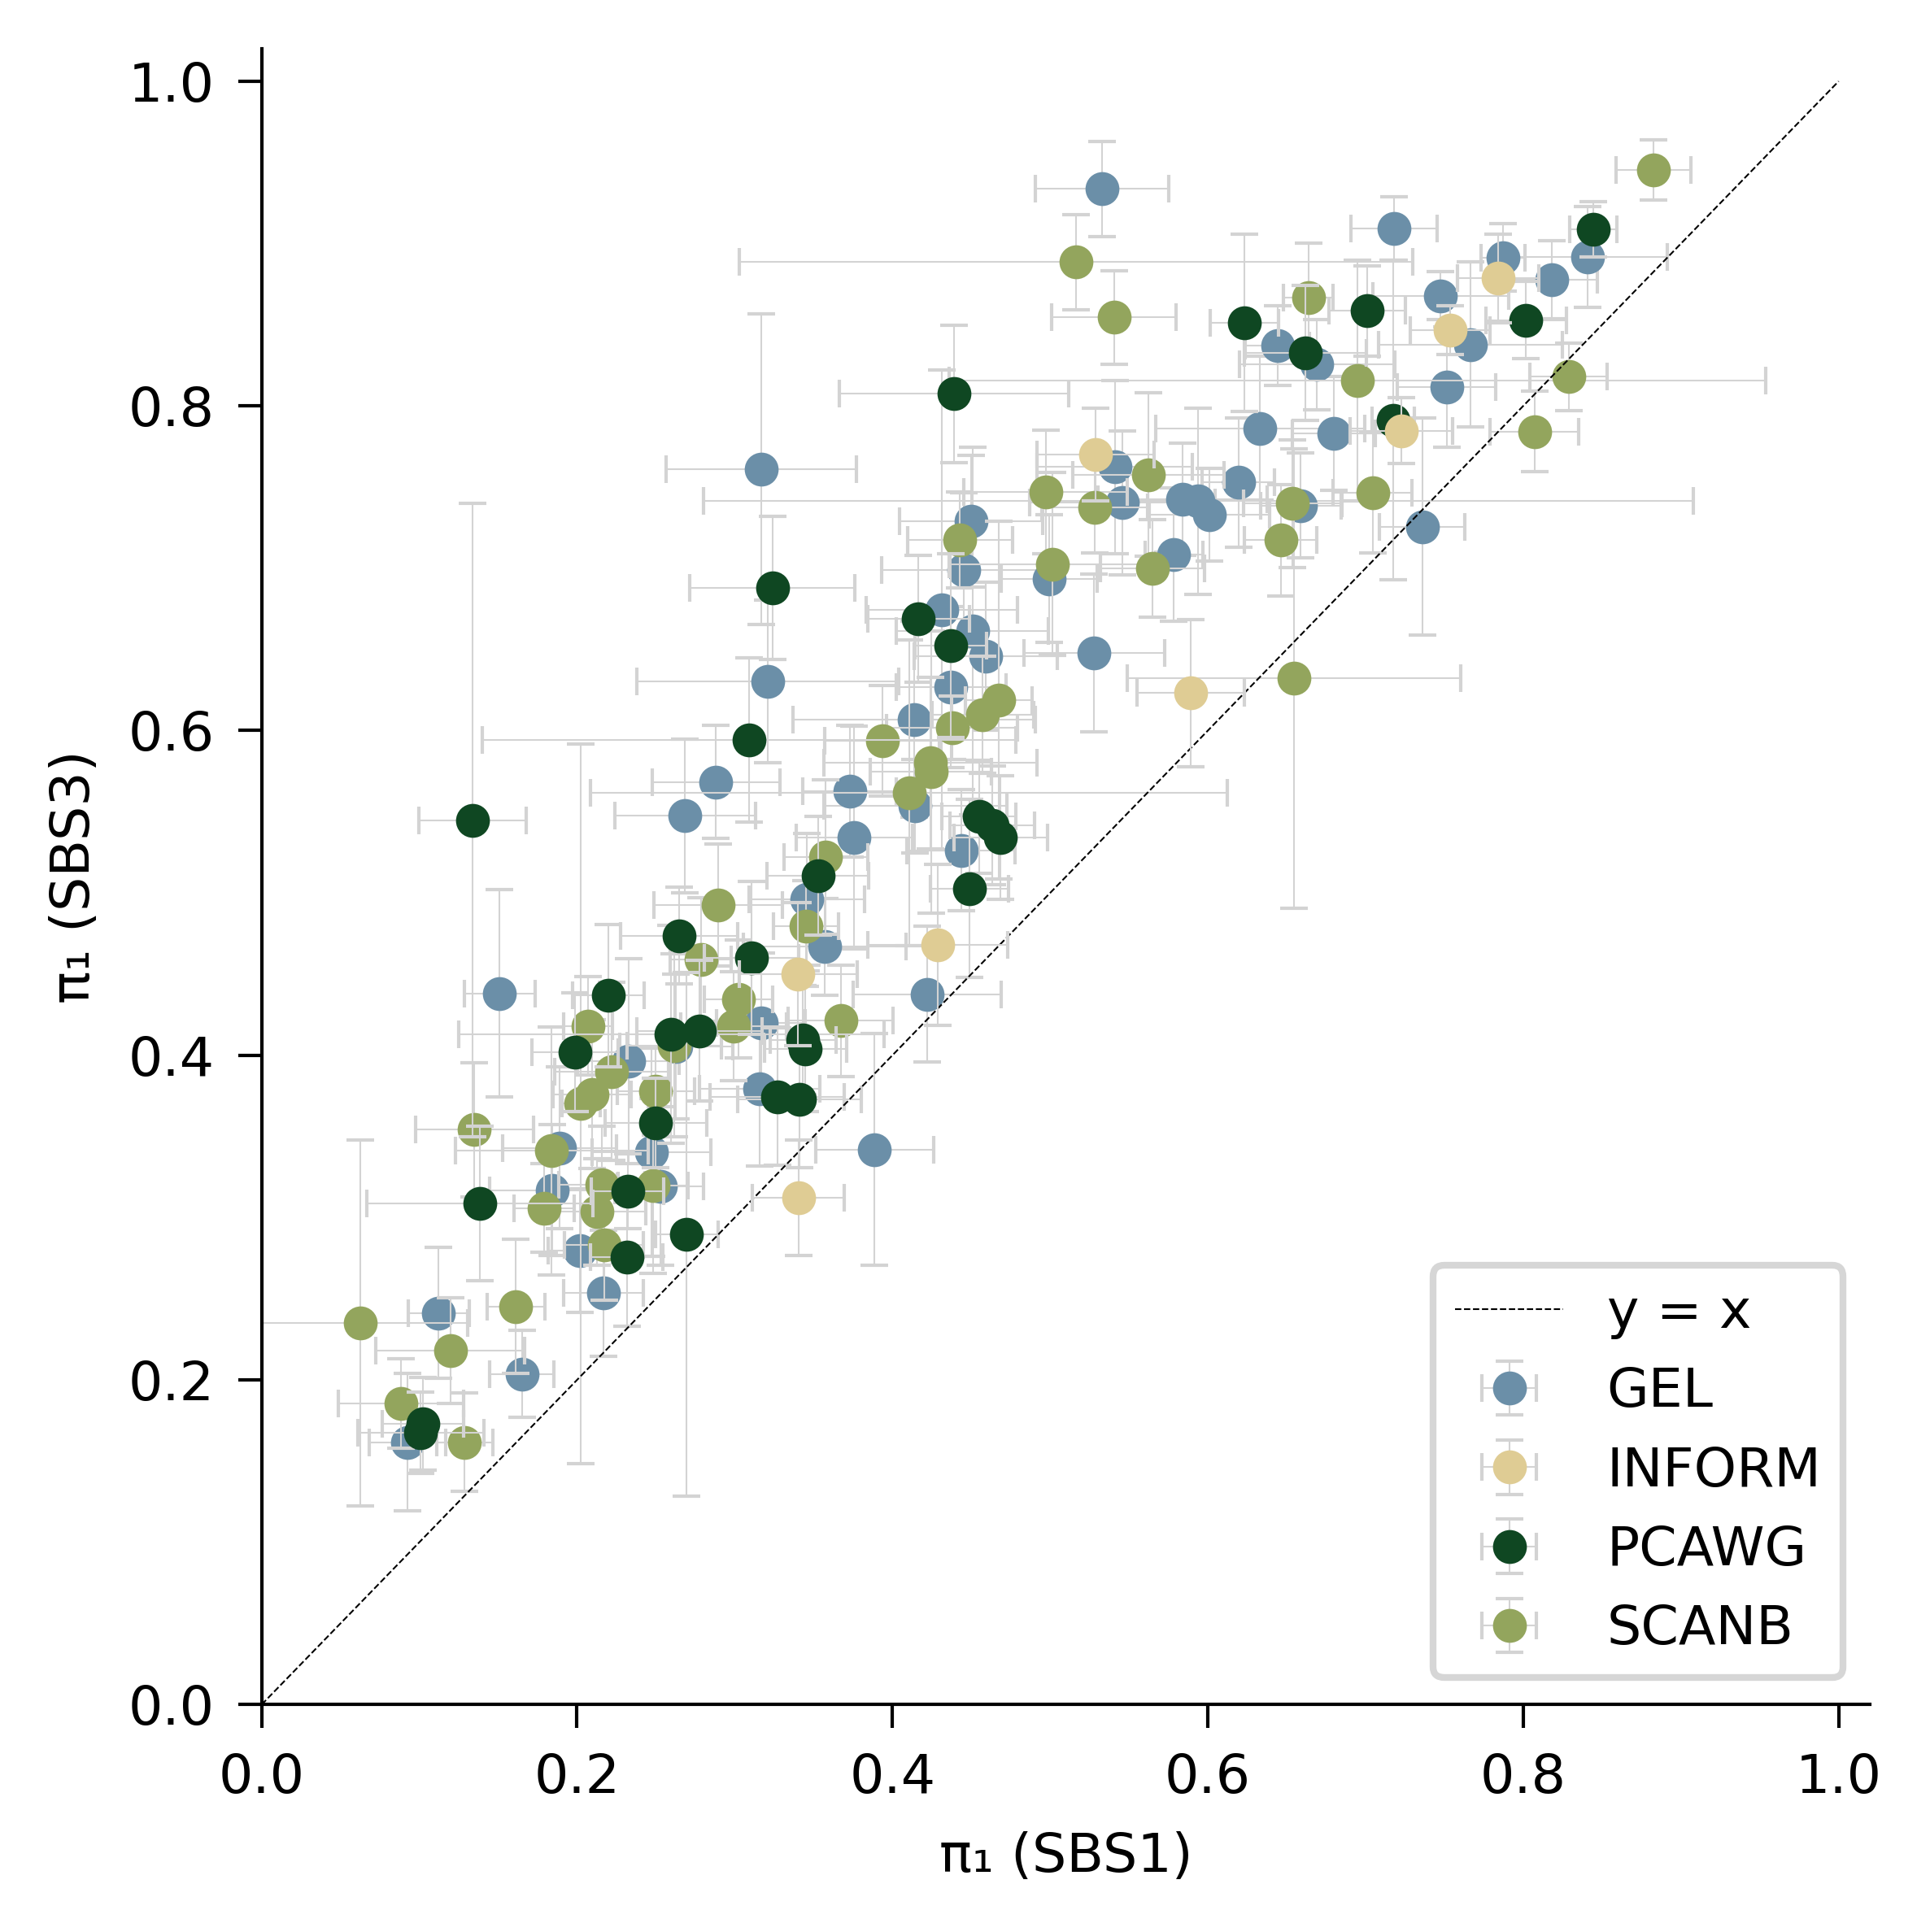

In [2]:
%matplotlib inline
# All timing / pi / exposure results for every cohort come from the v4 workbook (see OUT paths above).
results = pd.read_excel(V4_PATH, sheet_name="HRDTimer Estimates").rename(columns=S2_INV)

outlier_samples = []  # add sample IDs to exclude if needed

def parse_list(s):
    arr = np.array(eval(s, {"nan": np.nan}), dtype=float)
    return arr[[0, 2]] if len(arr) == 3 else arr

def weighted_mean_and_propagated_error(values, errors, weights):
    values, errors, weights = map(np.array, (values, errors, weights))
    mask = ~np.isnan(values)
    if not np.any(mask):
        return np.nan, np.nan
    values, errors, weights = values[mask], errors[mask], weights[mask]
    mean = np.average(values, weights=weights)
    error = np.sqrt(np.sum((weights * errors) ** 2) / np.sum(weights) ** 2)
    return mean, error

records = []
for label, df in results.groupby("cohort"):
    df = df.dropna(subset=['pi1SBS1', 'pi1SBS3', 'pi1SBS1_ci', 'pi1SBS3_ci', 'N_mut_all'])
    for _, row in df.iterrows():
        if row['sample'] in outlier_samples:
            continue
        weights = parse_list(row['N_mut_all'])
        m1, e1 = weighted_mean_and_propagated_error(parse_list(row['pi1SBS1']), parse_list(row['pi1SBS1_ci']), weights)
        m3, e3 = weighted_mean_and_propagated_error(parse_list(row['pi1SBS3']), parse_list(row['pi1SBS3_ci']), weights)
        records.append({'ID': row['sample'], 'Dataset': label, 'SBS1': m1, 'SBS1_err': e1, 'SBS3': m3, 'SBS3_err': e3})

plot_df = pd.DataFrame(records)

# Plot
colors = {'INFORM': '#DFCC94', 'SCANB': '#93A55D', 'PCAWG': '#0F4722', 'GEL': '#6B8FA8'}
# draw order (bottom -> top): SCANB, PCAWG, INFORM
ZORDER = {'GEL': 0, 'SCANB': 1, 'PCAWG': 2, 'INFORM': 3}
plt.figure(figsize=(4, 4))
for d, sub in plot_df.groupby('Dataset'):
    plt.errorbar(sub['SBS1'], sub['SBS3'], xerr=sub['SBS1_err'], yerr=sub['SBS3_err'],
             fmt='o', label=d, color=colors[d], ecolor='lightgrey', capsize=2,
             markersize=4, elinewidth=0.25, capthick=0.5, zorder=ZORDER.get(d, 1))
x = np.linspace(0, 1, 100)
plt.plot(x, x, 'k--', label='y = x', linewidth=0.25)
plt.xlabel("π₁ (SBS1)")
plt.ylabel("π₁ (SBS3)")
plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/All_Cohorts_pi1SBS3_vs_pi1SBS1_incGEL.pdf", format='pdf', bbox_inches='tight')
plt.show()

## Compare early and late SBS3 vs SBS1 correlation across cohorts

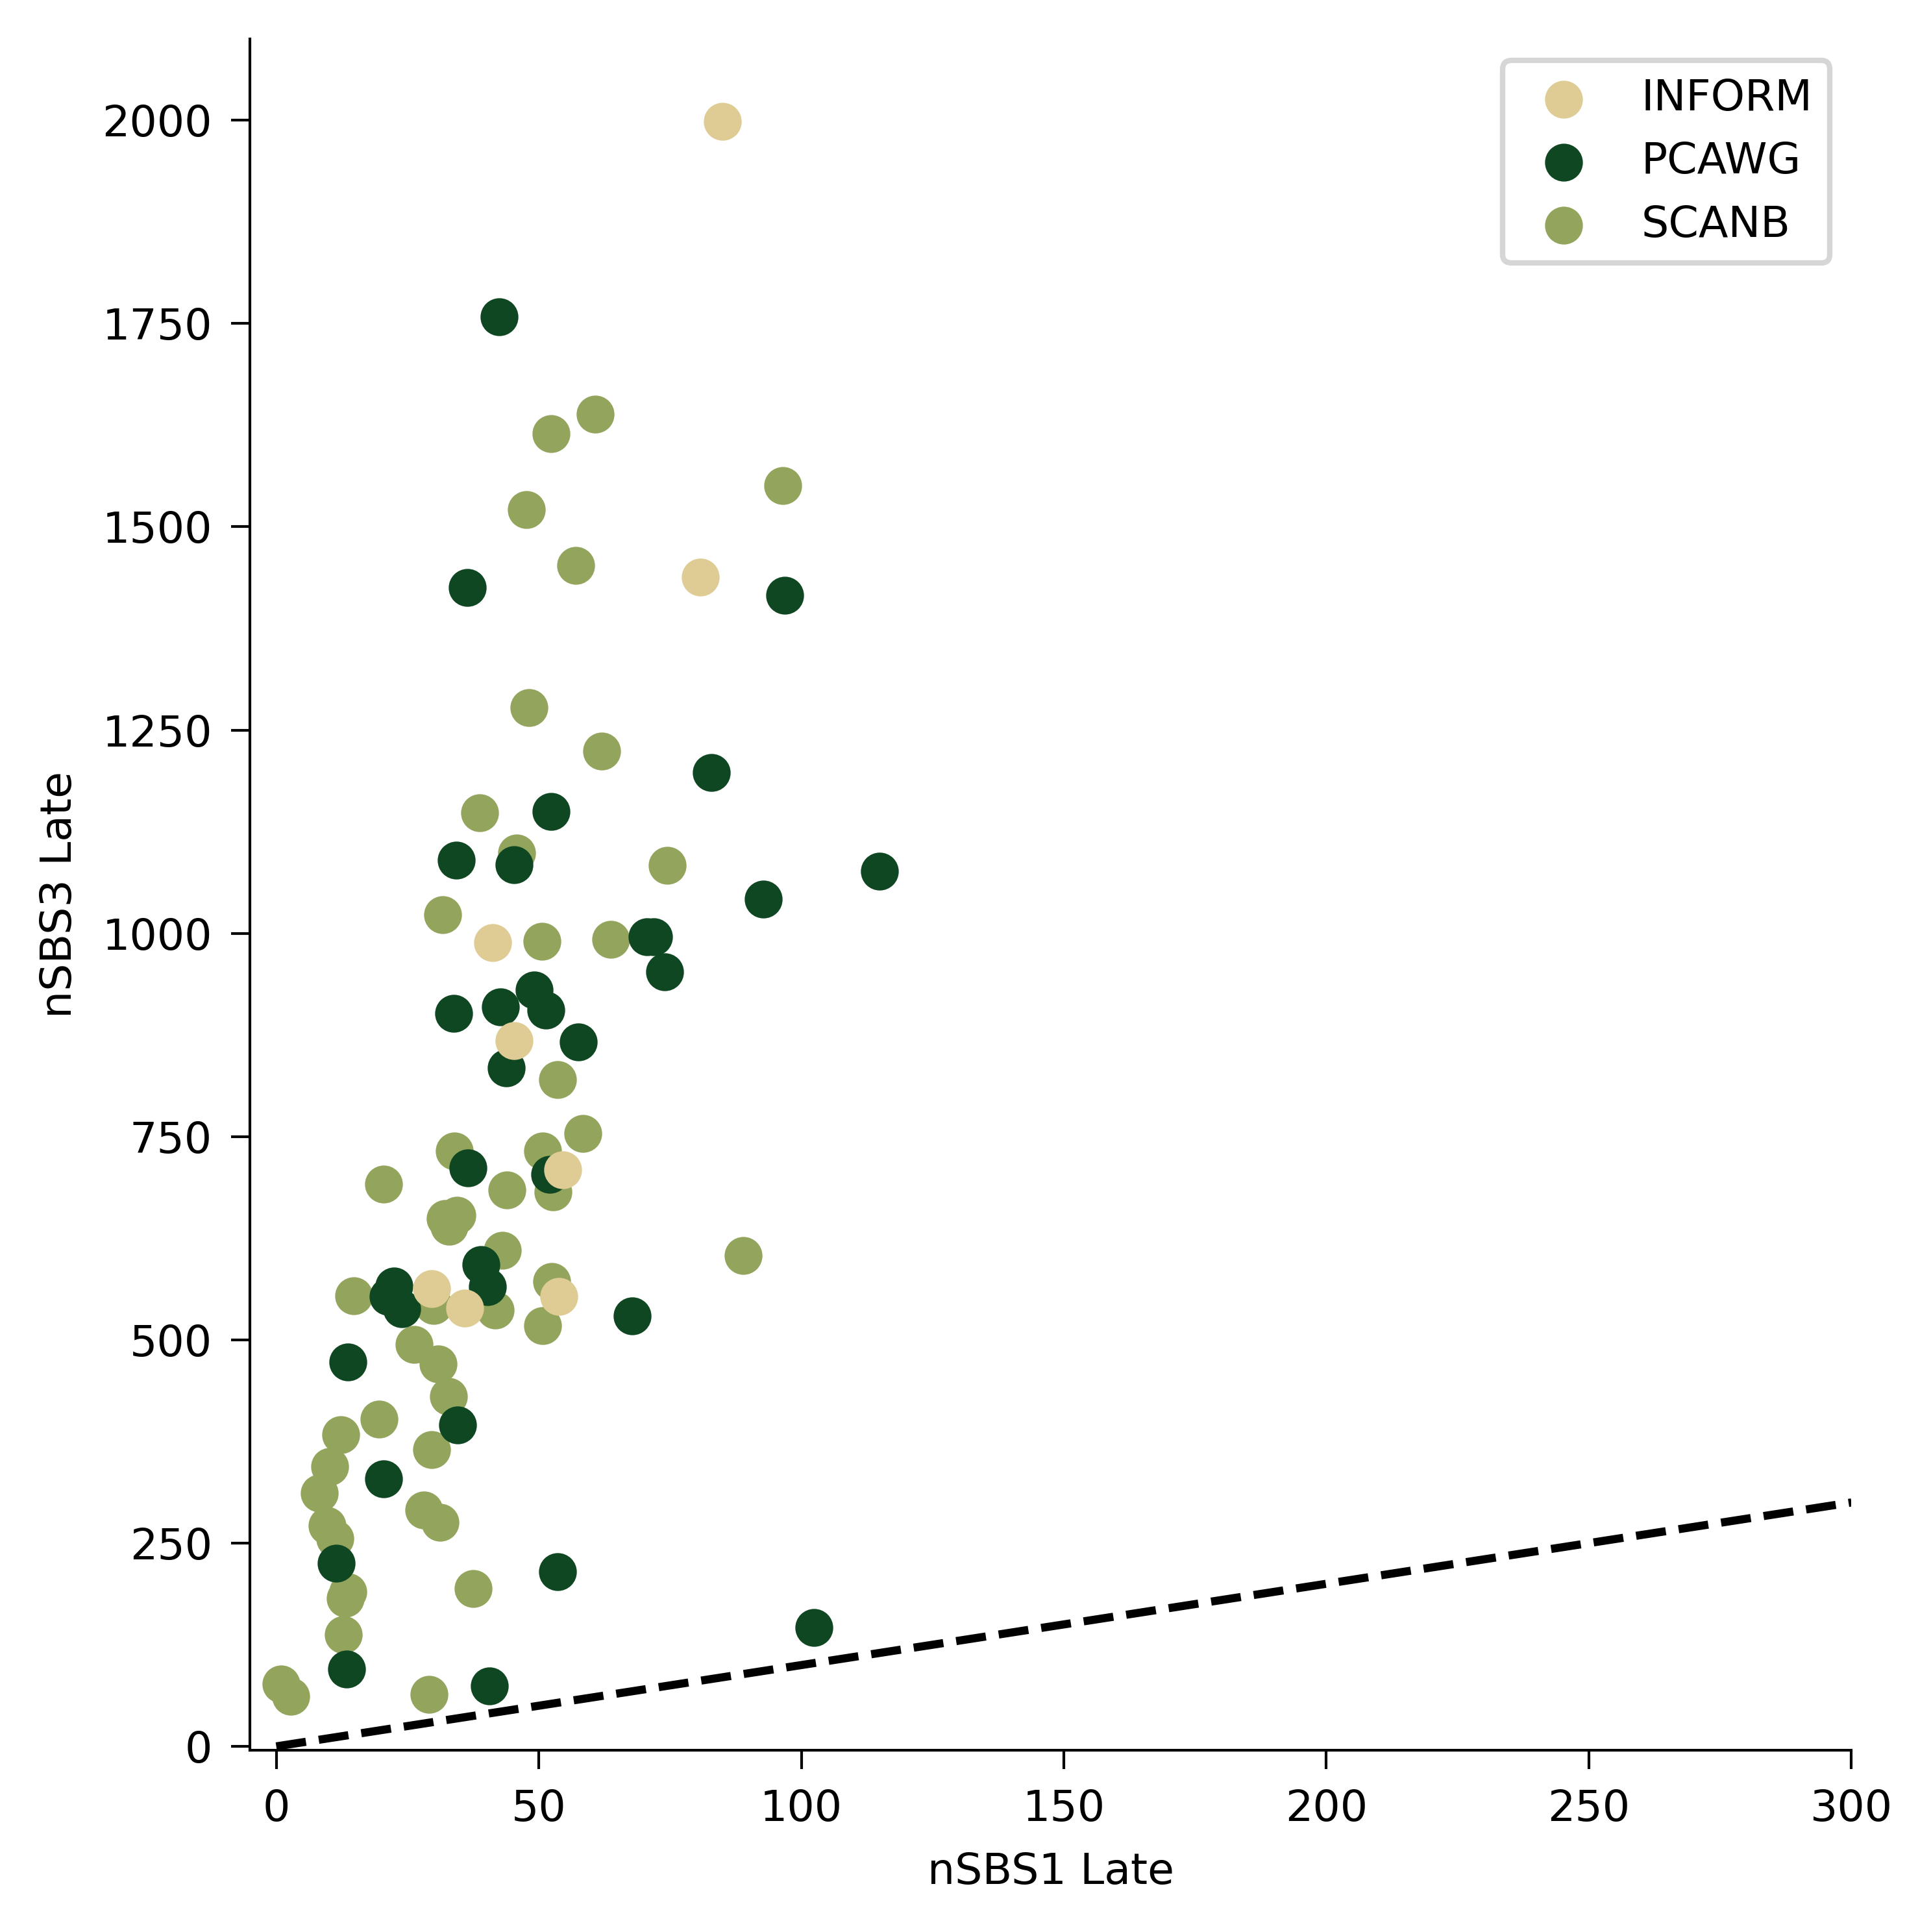

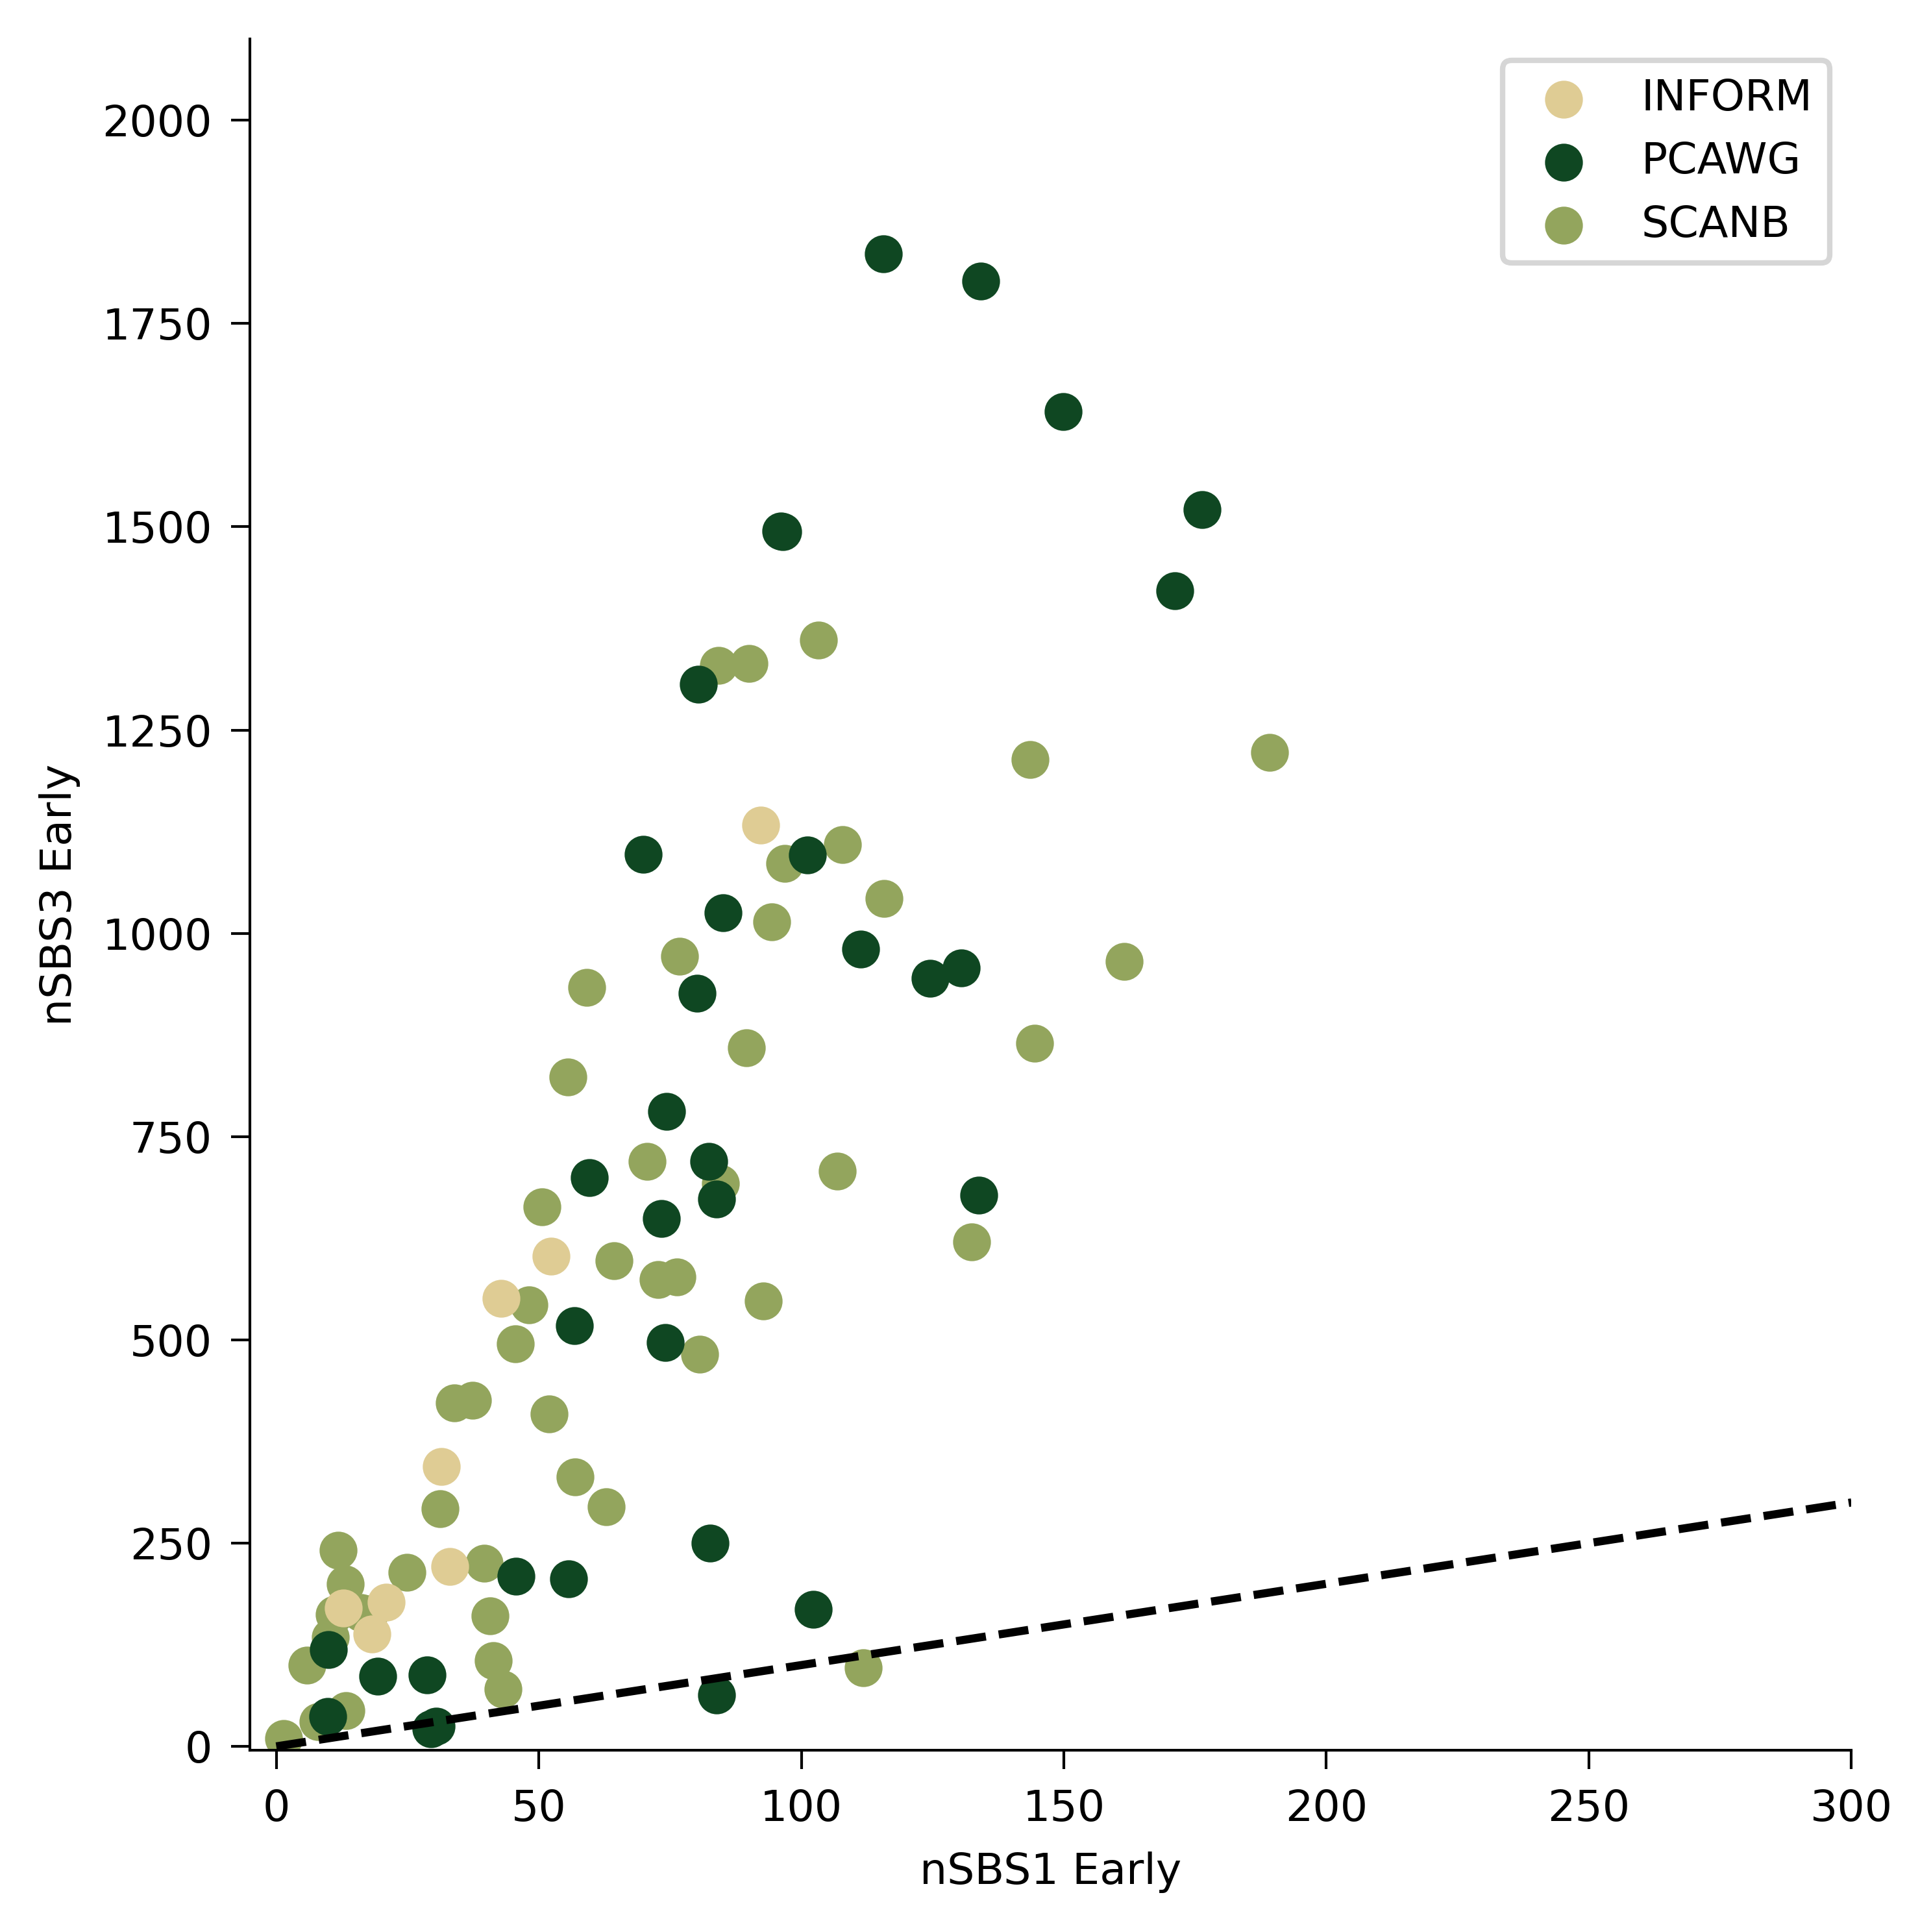

In [3]:
def parse_list(s):
    return np.array(eval(s, {"nan": np.nan}), dtype=float)

def keep_first_and_third(arr):
    if len(arr) < 3:
        return arr
    return np.array([arr[0], arr[2]])

def late_early_sums(row):
    pi1_1 = keep_first_and_third(parse_list(row['pi1SBS1']))
    pi1_3 = keep_first_and_third(parse_list(row['pi1SBS3']))
    pi2_1 = keep_first_and_third(parse_list(row['pi2SBS1']))
    pi2_3 = keep_first_and_third(parse_list(row['pi2SBS3']))
    nt_1  = keep_first_and_third(parse_list(row['Nt_SBS1']))
    nt_3  = keep_first_and_third(parse_list(row['Nt_SBS3']))
    return (np.nansum(pi1_1 * nt_1), np.nansum(pi1_3 * nt_3),
            np.nansum(pi2_1 * nt_1), np.nansum(pi2_3 * nt_3))

records = []
for label, df in results[results['cohort'] != 'GEL'].groupby('cohort'):
    for _, row in df.dropna(subset=['pi1SBS1', 'pi1SBS3', 'Nt_SBS1', 'Nt_SBS3', 'pi2SBS1', 'pi2SBS3']).iterrows():
        l1, l3, e1, e3 = late_early_sums(row)
        records.append({'Dataset': label, 'ID': row['sample'], 'passed_qc': row.get('passed_qc'),
                        'SBS1_Late': l1, 'SBS3_Late': l3, 'SBS1_Early': e1, 'SBS3_Early': e3})
plot_df = pd.DataFrame(records)

# Late / Early scatters (cohort-coloured) — all non-GEL samples, as in the original
colors = {'INFORM': '#DFCC94', 'SCANB': '#93A55D', 'PCAWG': '#0F4722'}
for metric_x, metric_y, tag in [('SBS1_Late', 'SBS3_Late', 'Late'), ('SBS1_Early', 'SBS3_Early', 'Early')]:
    plt.figure(figsize=(5, 5))
    for d in plot_df['Dataset'].unique():
        sub = plot_df[plot_df['Dataset'] == d]
        plt.scatter(sub[metric_x], sub[metric_y], label=d, color=colors[d], alpha=1, zorder=ZORDER.get(d, 1))
    plt.xlim(-5, 300); plt.ylim(-5, 2100)
    plt.plot([0, 300], [0, 300], 'k--')
    plt.xlabel(f"nSBS1 {tag}"); plt.ylabel(f"nSBS3 {tag}")
    plt.legend(); plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/All_Cohorts_{tag}_SBS3_vs_SBS1.pdf", format='pdf', bbox_inches='tight')
    plt.show()

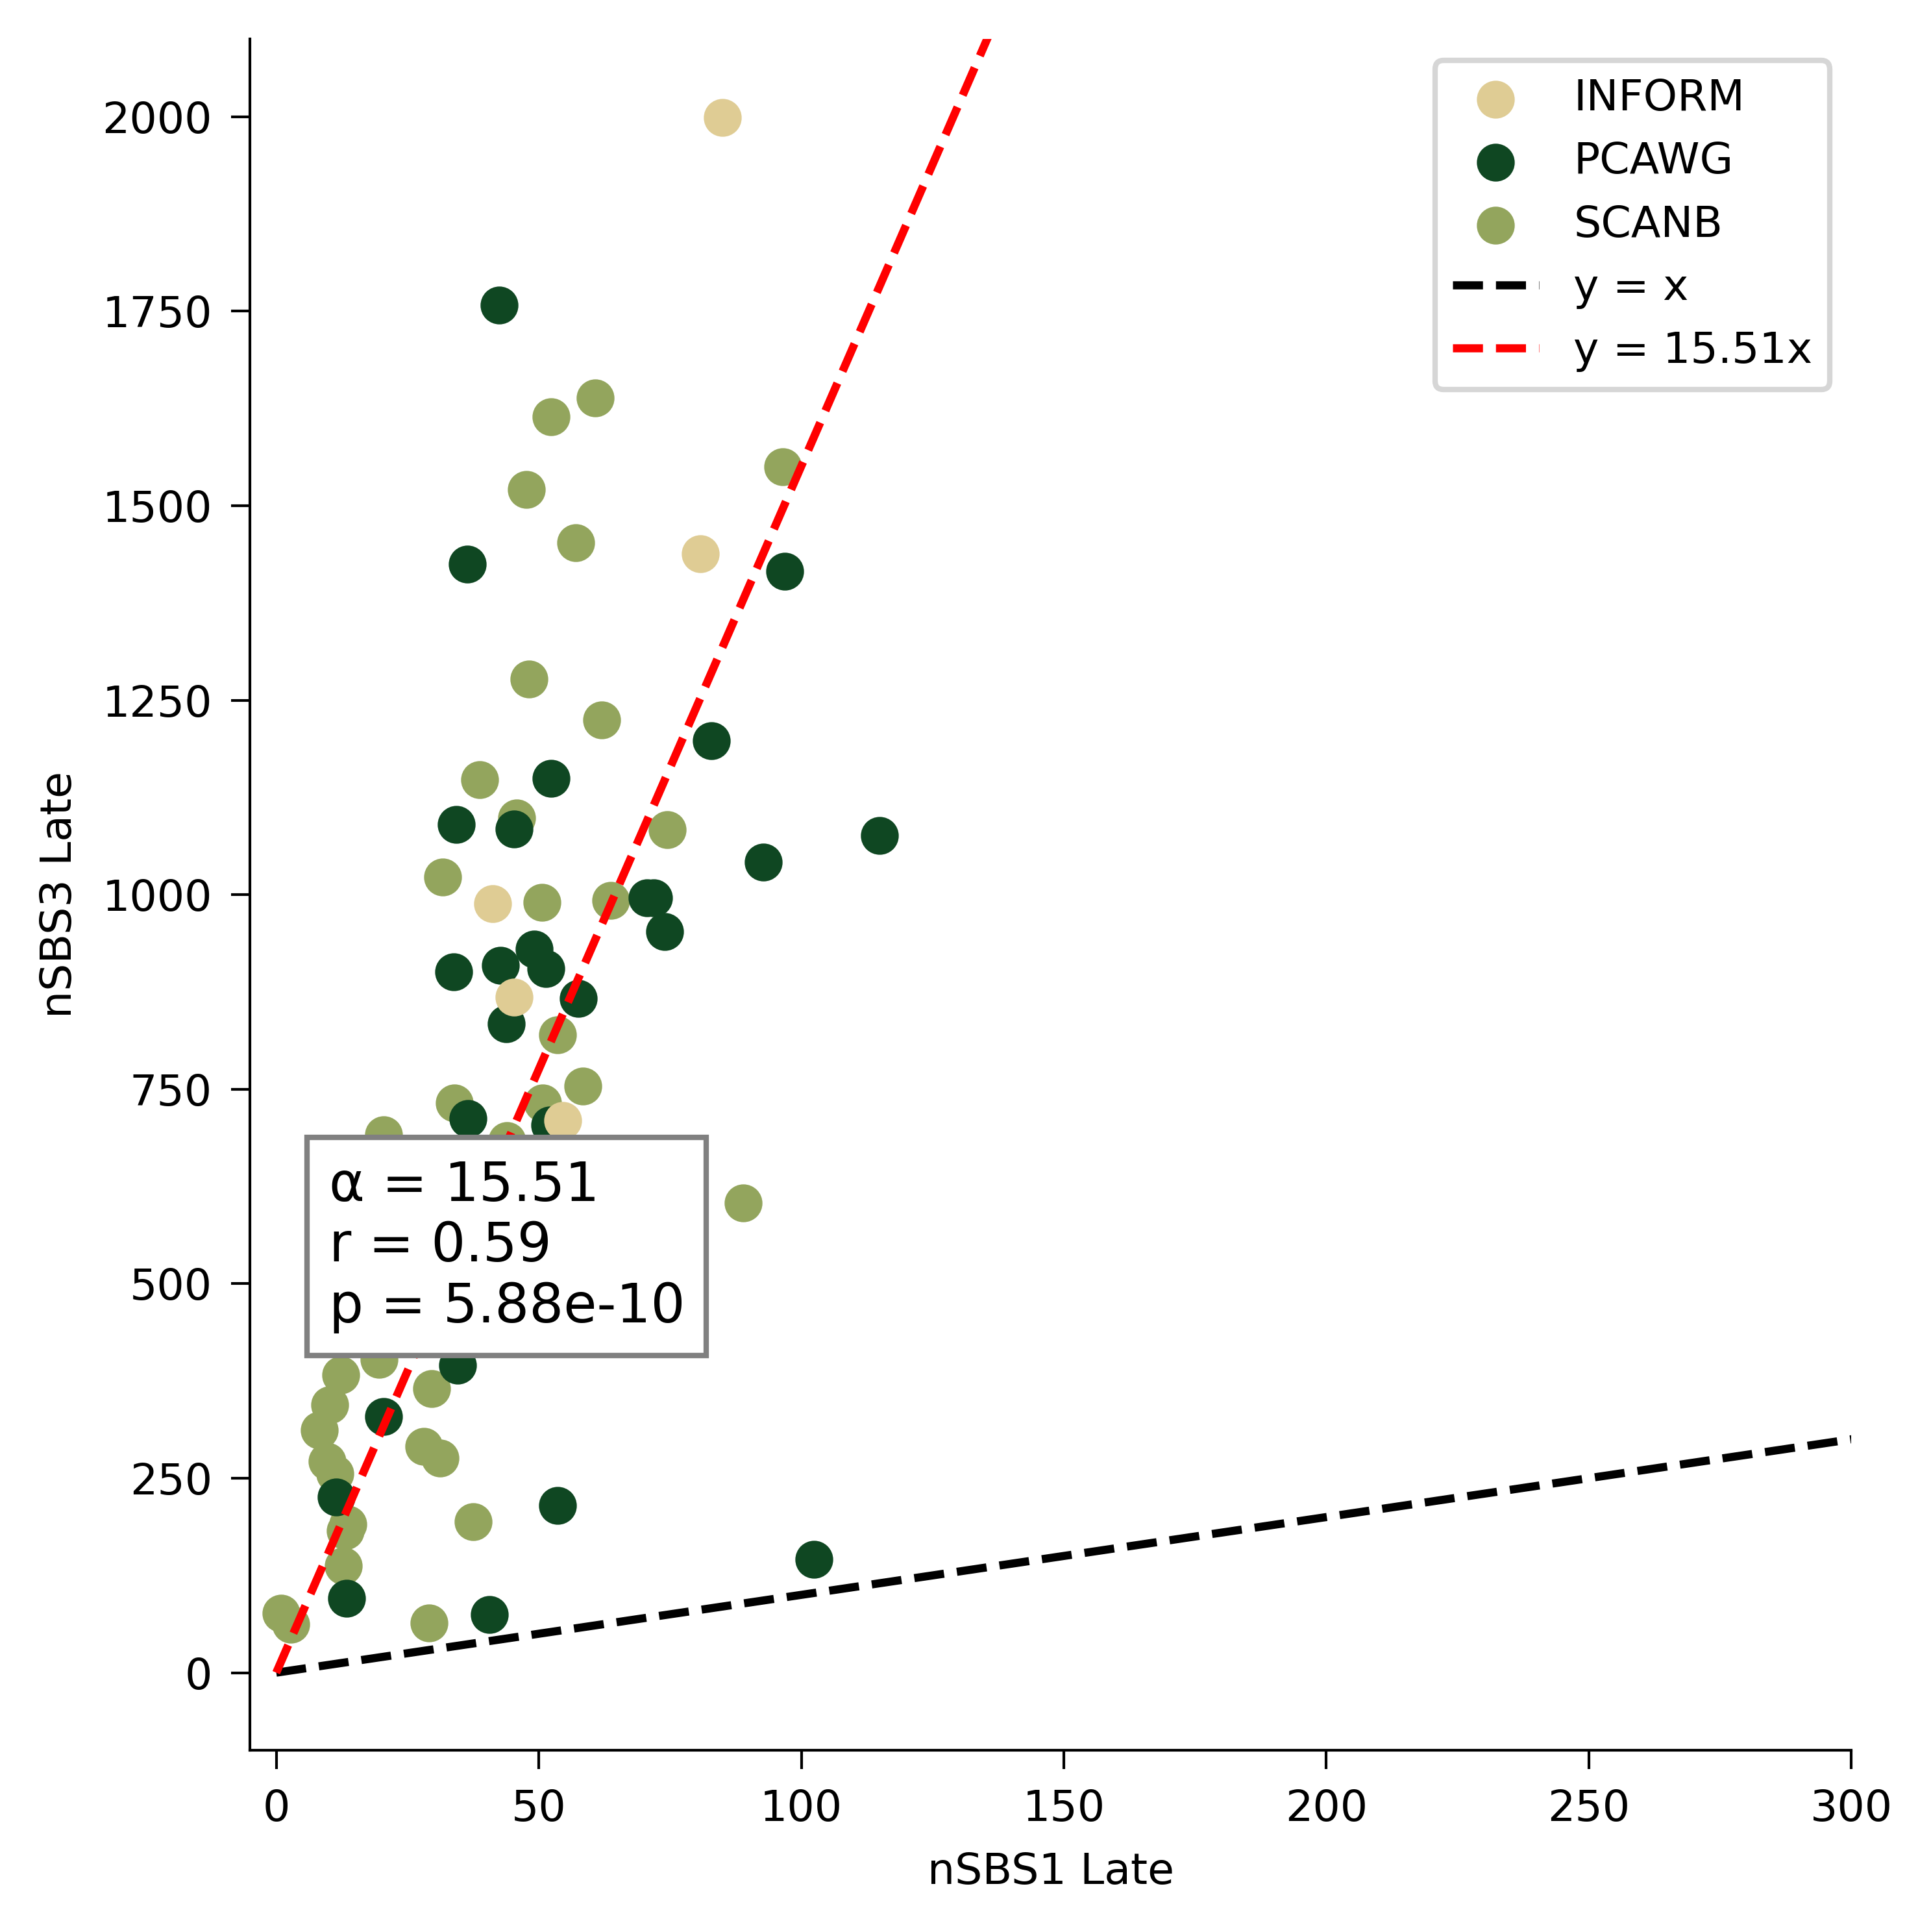

In [4]:
x = plot_df['SBS1_Late']
y = plot_df['SBS3_Late']

mask = ~np.isnan(x) & ~np.isnan(y)
x, y = x[mask], y[mask]

alpha = np.sum(x * y) / np.sum(x ** 2)
fitted = alpha * x
r, p = pearsonr(x, y)

# Plot
colors = {'INFORM': '#DFCC94', 'SCANB': '#93A55D', 'PCAWG': '#0F4722'}
plt.figure(figsize=(5, 5))
for d, sub in plot_df.groupby('Dataset'):
    xt = sub['SBS1_Late']
    yt = sub['SBS3_Late']
    plt.scatter(xt, yt, label=d, color=colors[d], zorder=ZORDER.get(d, 1))

plt.plot([0, 500], [0, 500], 'k--', label='y = x')
plt.plot([0, 500], [0, alpha * 500], 'r--', label=f'y = {alpha:.2f}x')
plt.text(10, 450, f"α = {alpha:.2f}\nr = {r:.2f}\np = {p:.2e}", fontsize=10,
         bbox=dict(facecolor='white', edgecolor='gray'))

plt.xlabel("nSBS1 Late")
plt.ylabel("nSBS3 Late")
plt.xlim(-5, 300)
plt.ylim(-100, 2100)
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/All_Cohorts_Late_SBS3_vs_SBS1_fit.pdf", format='pdf', bbox_inches='tight')
plt.show()


## Compare SBS1 exposures vs C>T substitutions at CpG contexts

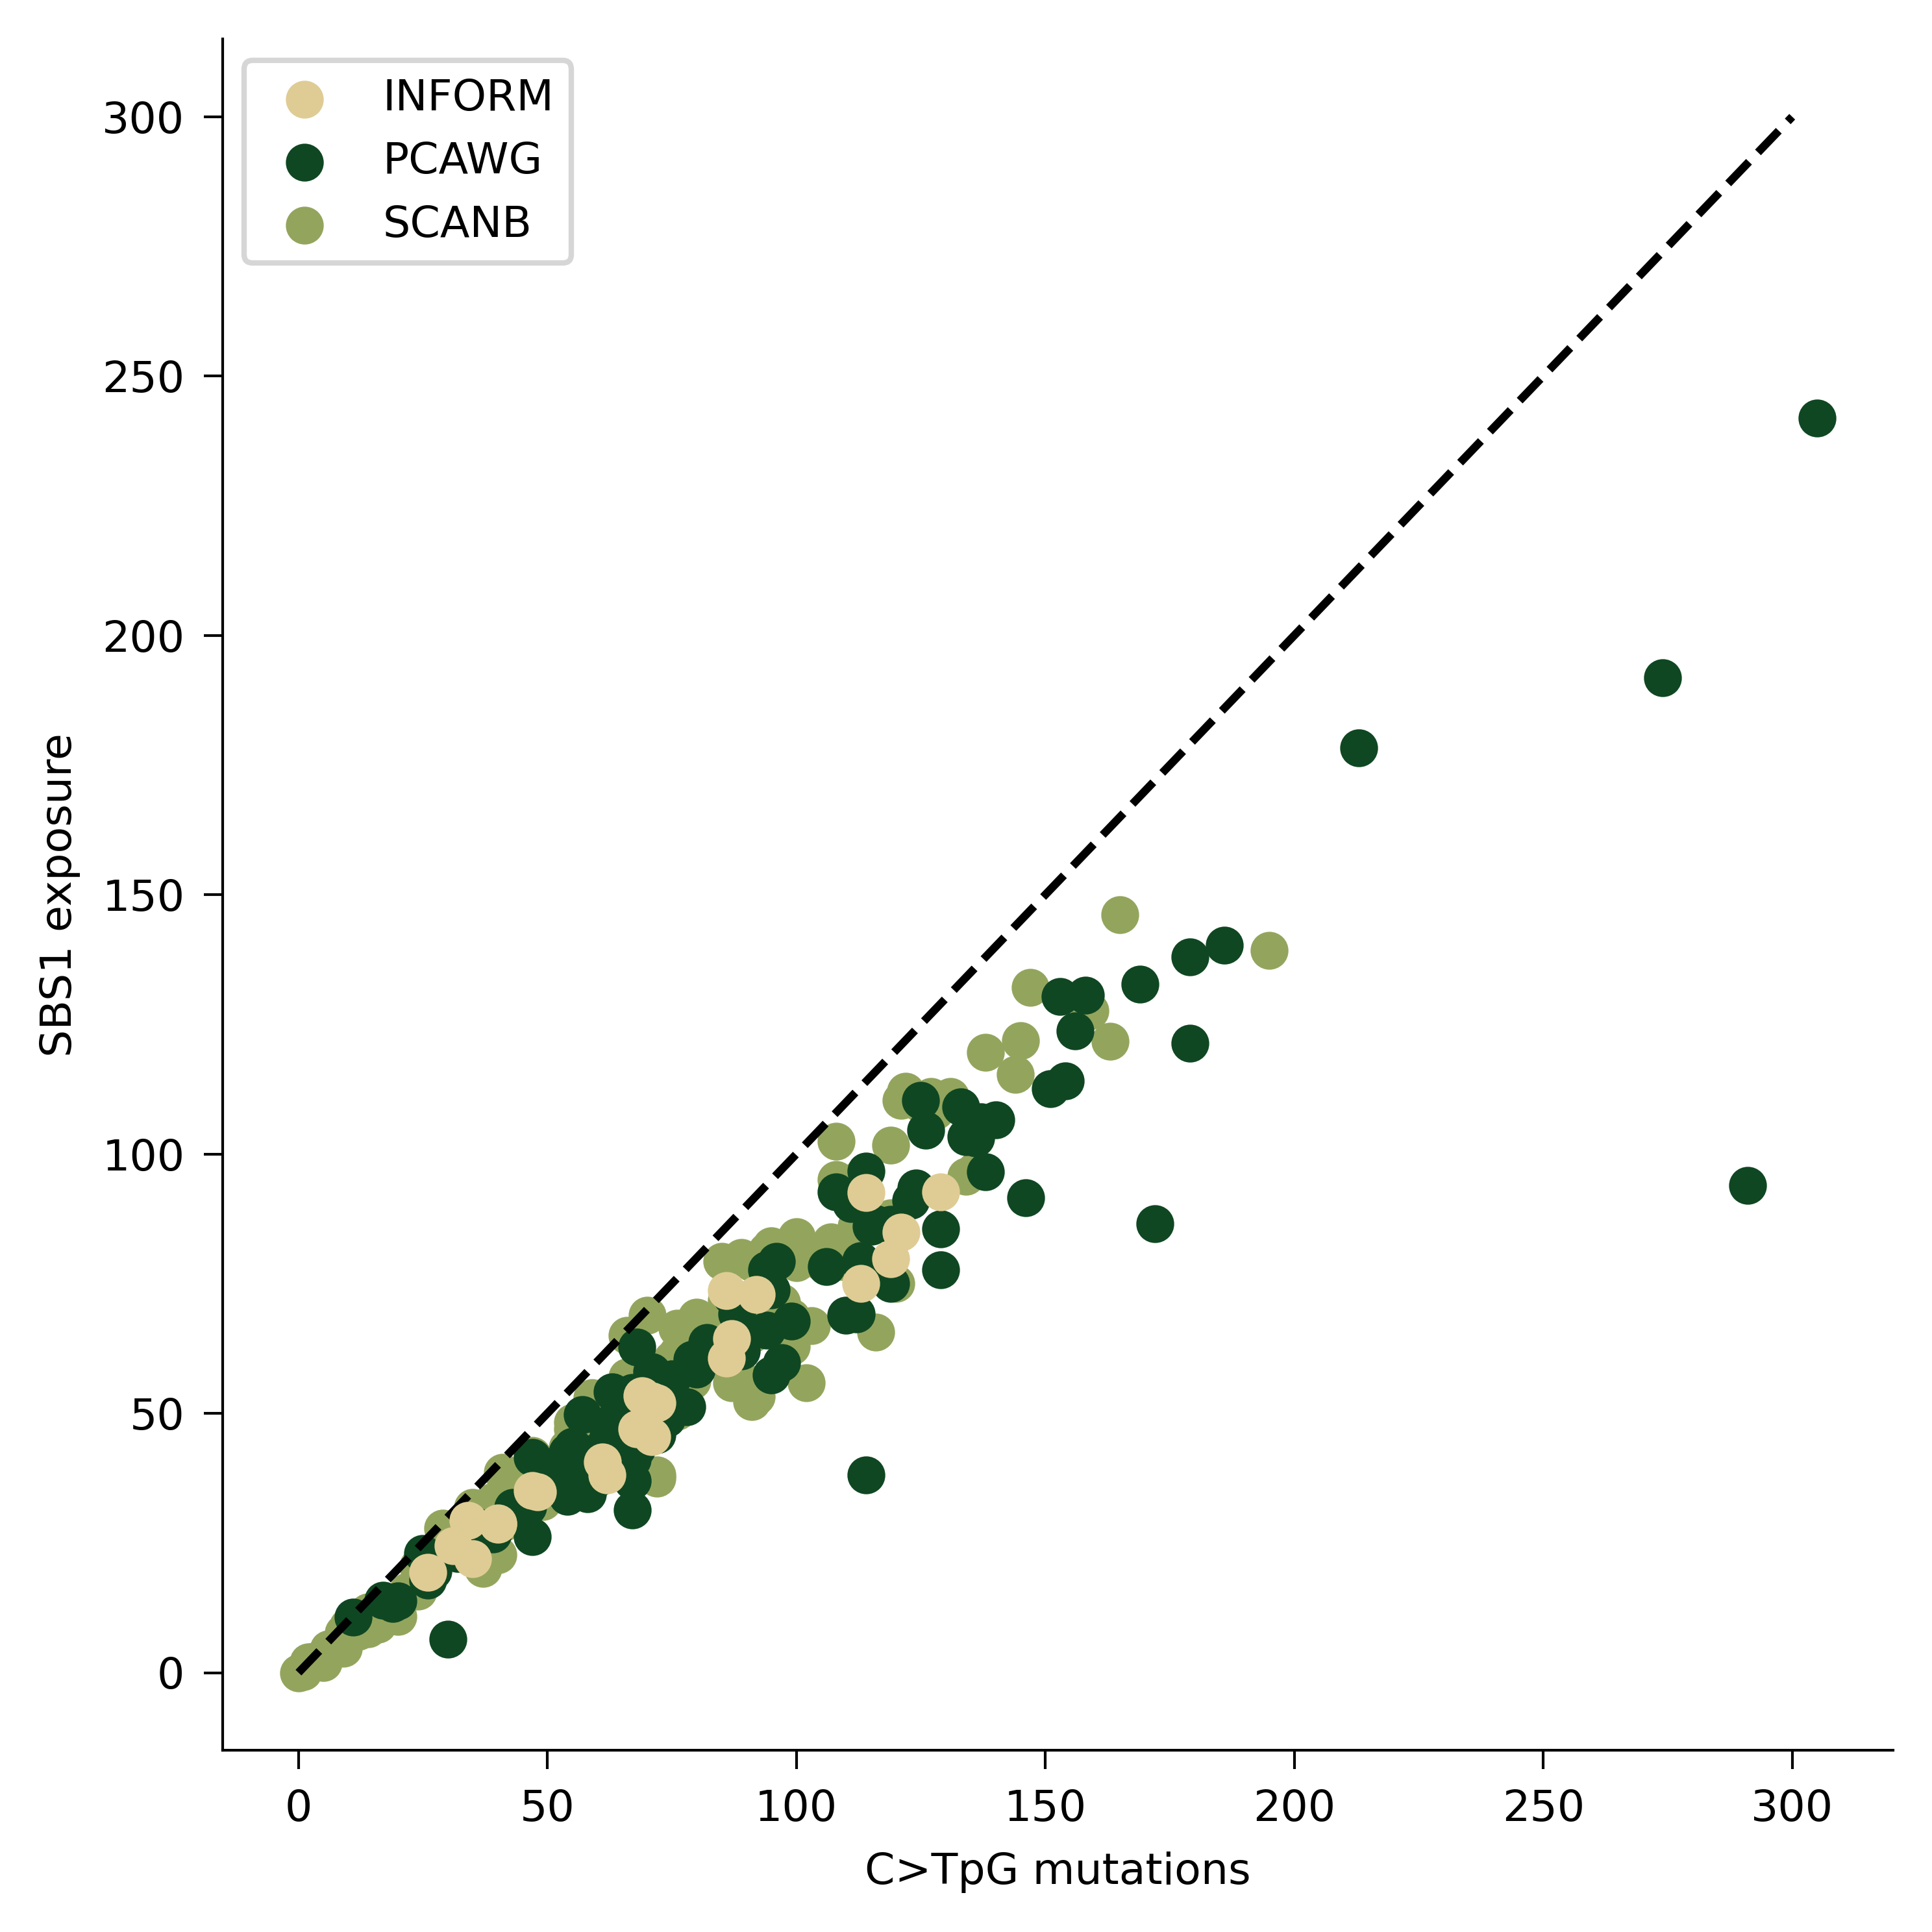

In [5]:
def parse_list(s): return np.array(eval(s, {"nan": np.nan}), dtype=float)

records = []
for label, df in results[results['cohort'] != 'GEL'].groupby('cohort'):
    for _, row in df.dropna(subset=['Nt_SBS1', 'N_mut_CpG']).iterrows():
        for x, y in zip(parse_list(row['Nt_SBS1']), parse_list(row['N_mut_CpG'])):
            records.append({'Dataset': label, 'Nt_SBS1': x, 'N_mut_CpG': y})
plot_df = pd.DataFrame(records)

plt.figure(figsize=(5, 5))
colors = {'INFORM': '#DFCC94', 'SCANB': '#93A55D', 'PCAWG': '#0F4722'}
for d in plot_df['Dataset'].unique():
    sub = plot_df[plot_df['Dataset'] == d]
    plt.scatter(sub['N_mut_CpG'], sub['Nt_SBS1'], label=d, color=colors[d], alpha=1, zorder=ZORDER.get(d, 1))
plt.plot([0, 300], [0, 300], 'k--')
plt.ylabel("SBS1 exposure"); plt.xlabel("C>TpG mutations")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/All_cohorts_CpG_vs_SBS1.pdf", format='pdf', bbox_inches='tight')
plt.show()

## Investigate how probability of assignment of a C>T substitution at CpG contexts vary across cohorts and time points (early vs late)

In [6]:
# Inlined from hrdtimer.utils so the notebook is self-contained.
def plot_sbs1_CpG_boxplot(
    cohort,
    sample_ids_csv_path,
    base_dir,
    output_path,
    contexts=['A[C>T]G', 'C[C>T]G', 'G[C>T]G', 'T[C>T]G'],
    sbs_column='SBS1',
    figsize=(3, 3)
):
    ids_to_include = pd.read_csv(sample_ids_csv_path)['ID'].tolist()

    dirs = {
        'Early': os.path.join(base_dir, 'Early/probabilities'),
        'Late':  os.path.join(base_dir, 'Late/probabilities'),
    }

    def process_file(file_path, period):
        df = pd.read_csv(file_path, sep='\t')
        df['Period'] = period
        sample_id = os.path.basename(file_path).split('_')[1]
        df['ID'] = sample_id
        df['MutationType'] = df['MutationType'].where(df['MutationType'].isin(contexts), 'Other')
        return df.groupby(['MutationType', 'Period', 'ID'], as_index=False)[sbs_column].mean()

    all_data = pd.concat(
        process_file(os.path.join(dirs[period], f), period)
        for period in dirs
        for f in os.listdir(dirs[period])
        if f.endswith('.txt')
    )

    filtered_data = all_data[all_data['ID'].isin(ids_to_include)]
    ordered_types = contexts + ['Other']
    filtered_data['MutationType'] = pd.Categorical(filtered_data['MutationType'], categories=ordered_types, ordered=True)

    plt.figure(figsize=figsize)
    palette = {'Early': 'grey', 'Late': to_rgba('lightgrey', alpha=0.1)}
    sns.boxplot(
        x='MutationType', y=sbs_column, hue='Period', data=filtered_data, palette=palette, fliersize=1.8,
        boxprops=dict(edgecolor='black', linewidth=0.4),
        whiskerprops=dict(color='black', linewidth=0.4),
        capprops=dict(color='black', linewidth=0.4),
        medianprops=dict(color='black'),
        flierprops=dict(markeredgecolor='black', linewidth=0.5),
    )
    for i in range(1, len(ordered_types)):
        plt.axvline(i - 0.5, color='grey', linestyle='--', linewidth=0.5)
    plt.ylim(0, 1)
    plt.title(cohort)
    plt.xlabel('Mutation Type')
    plt.ylabel(f'{sbs_column} Probability')
    plt.legend(title='Period', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    plt.show()

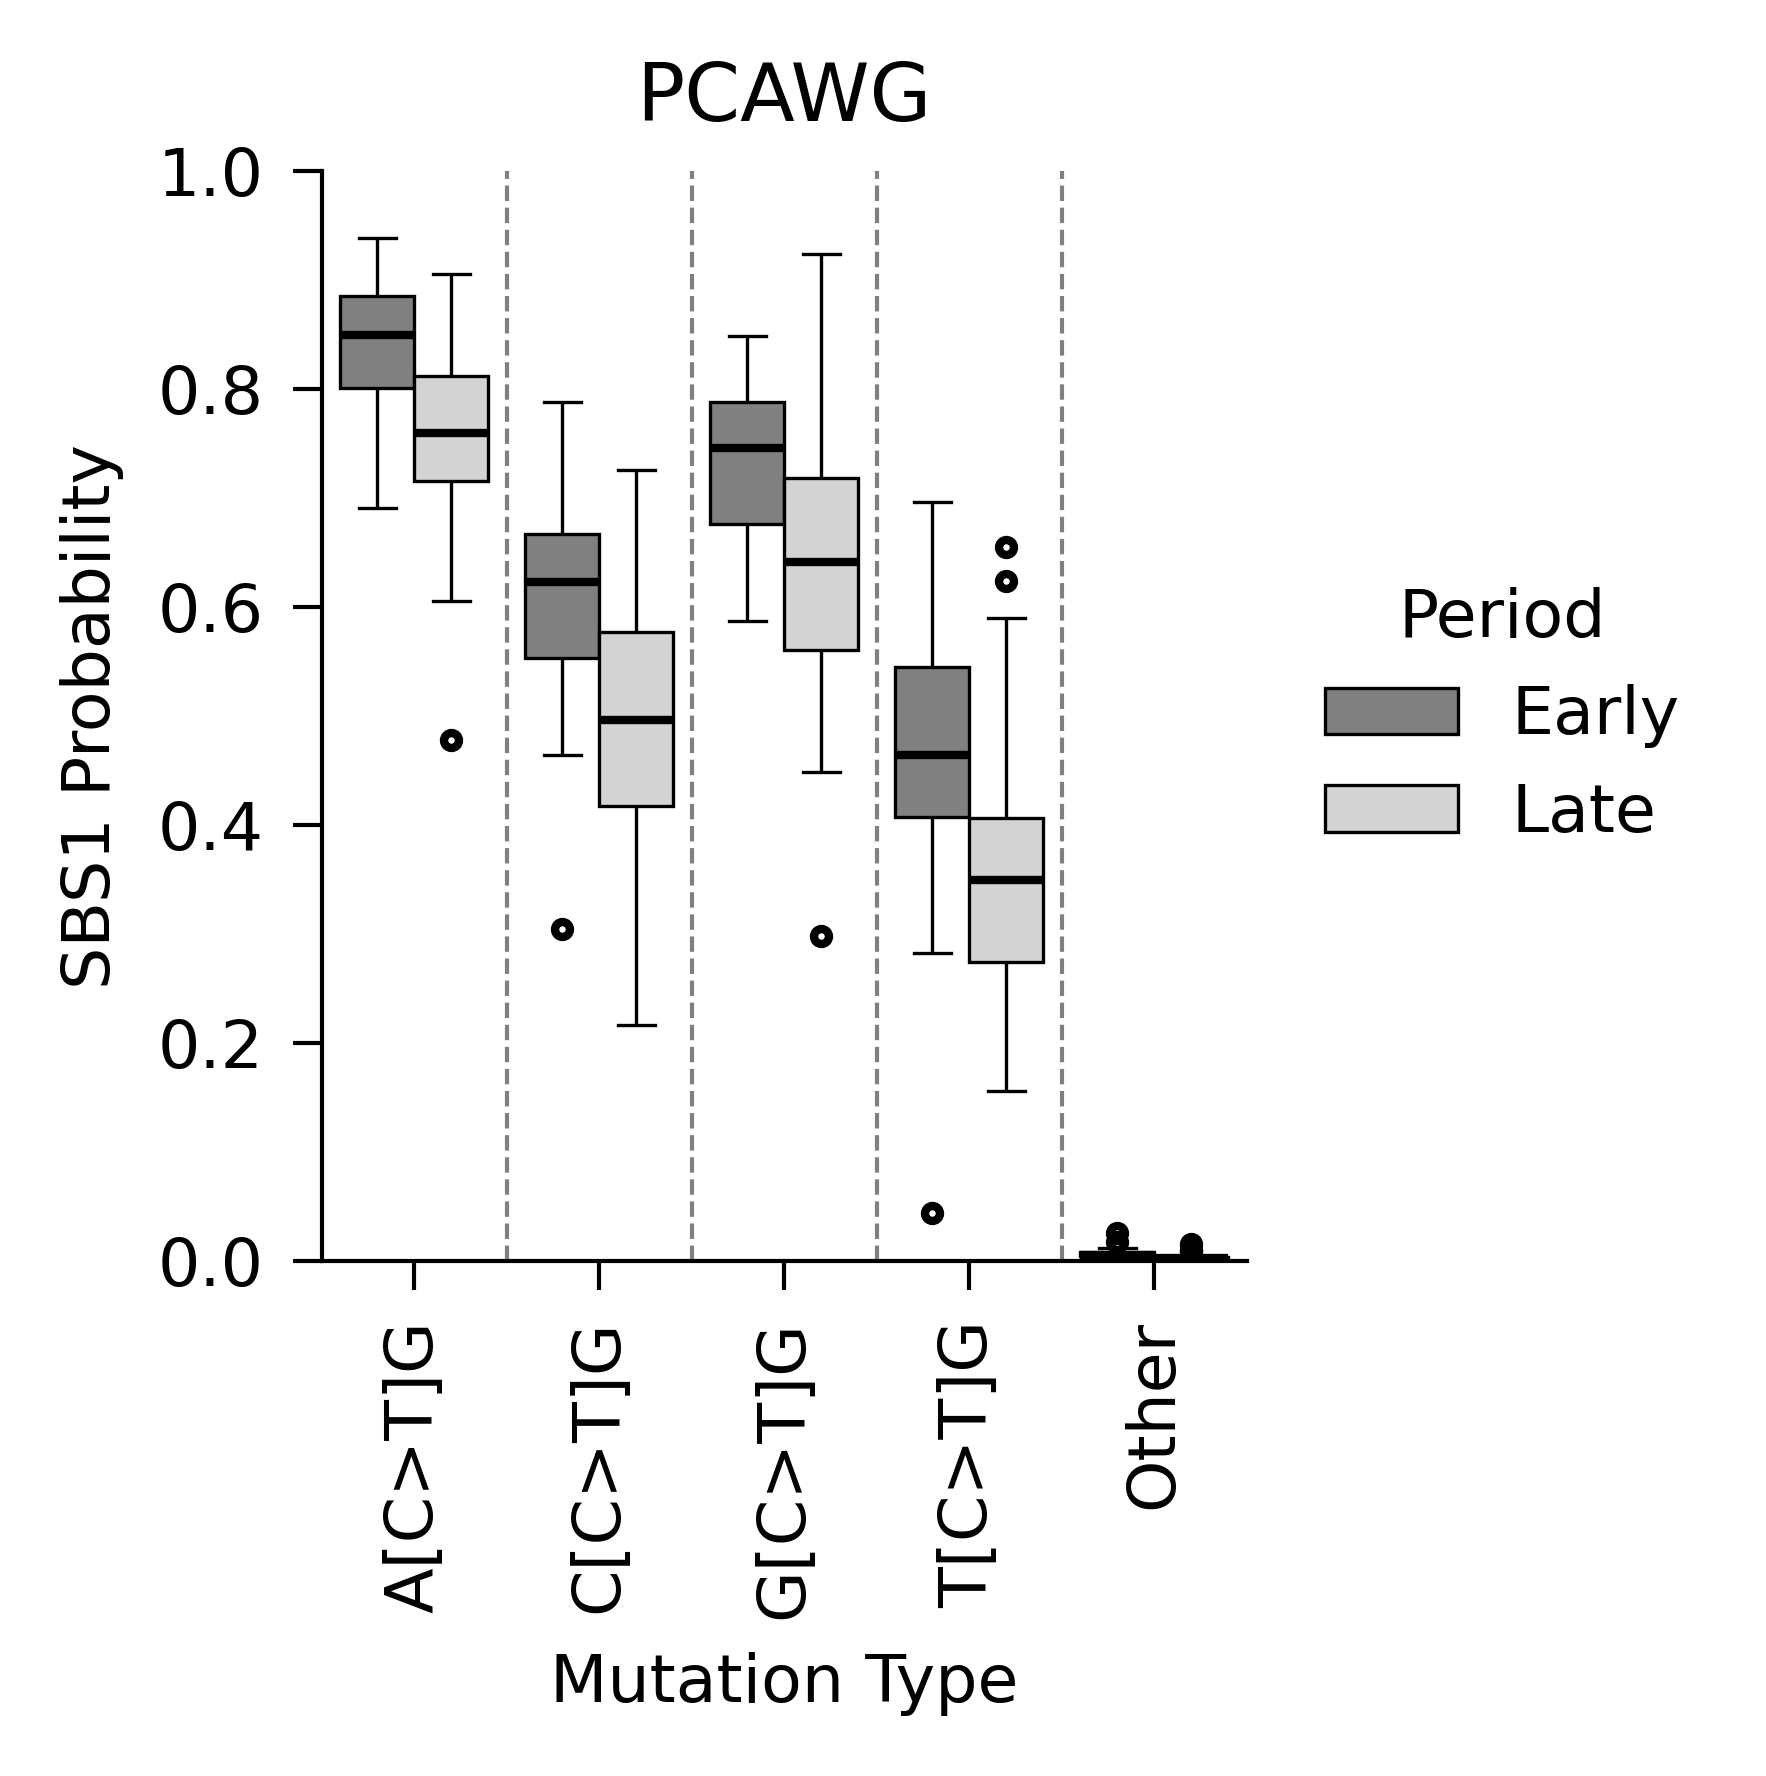

In [7]:
plot_sbs1_CpG_boxplot(
    cohort='PCAWG',
    sample_ids_csv_path=f"{TIMING_DIR}/PCAWG{TIMING_SUFFIX}",
    base_dir=f"{PREPROCESS_DIR}/PCAWG",
    output_path=f"{OUT_DIR}/SBS1_PCAWG_prob.pdf",
)

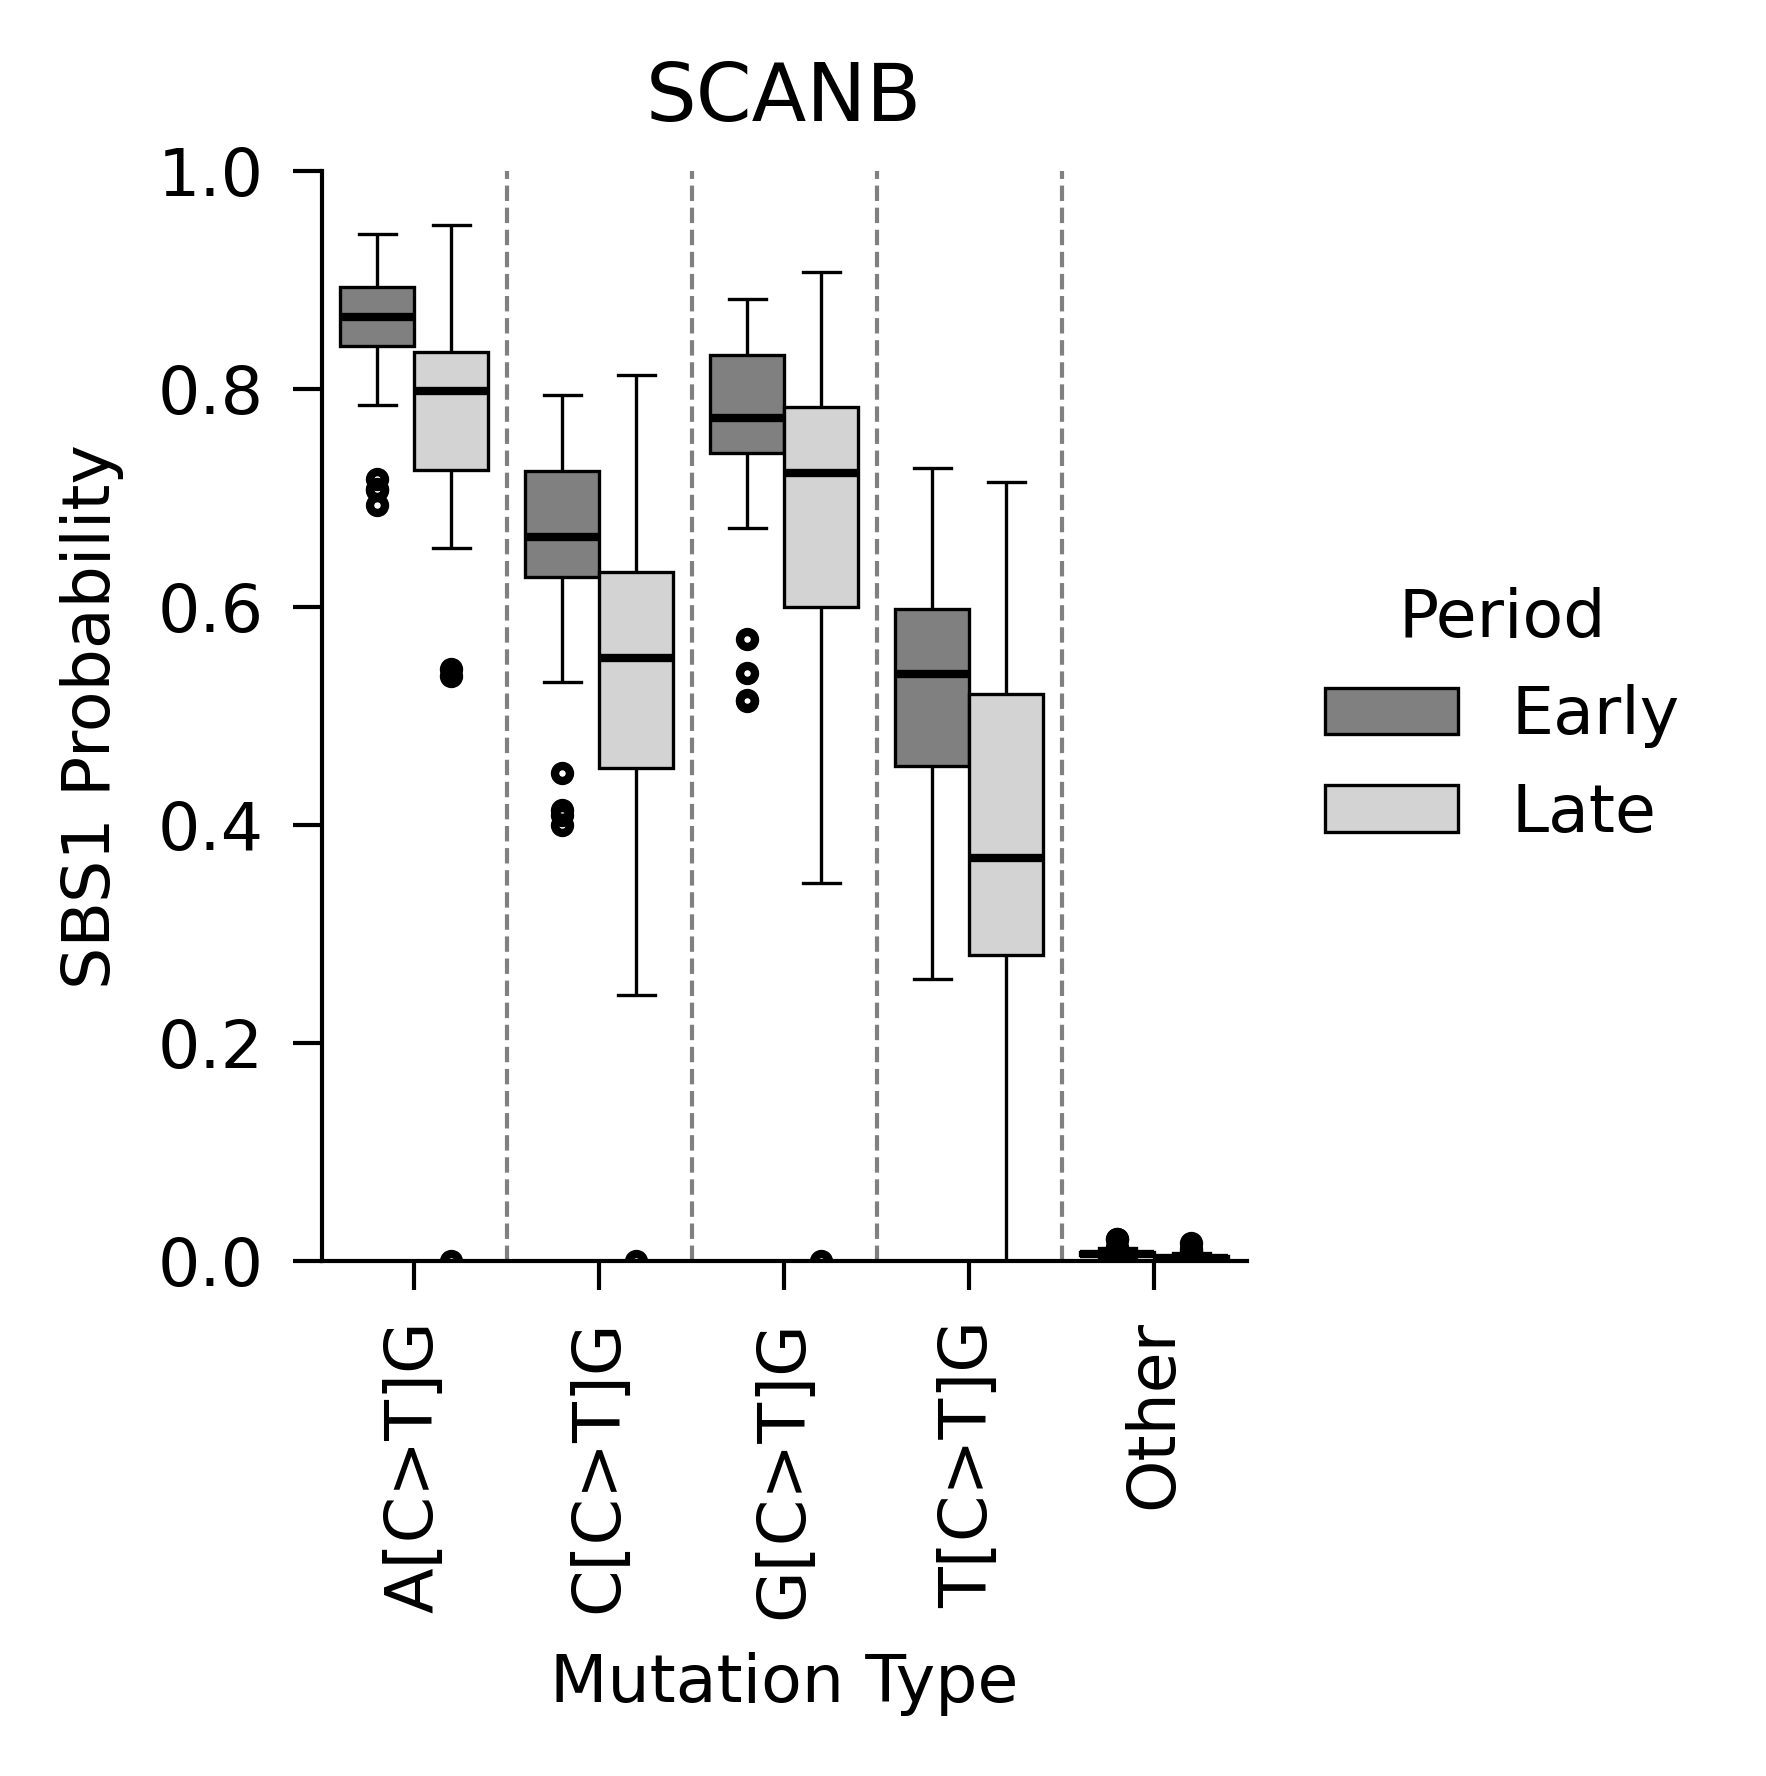

In [8]:
plot_sbs1_CpG_boxplot(
    cohort='SCANB',
    sample_ids_csv_path=f"{TIMING_DIR}/SCANB{TIMING_SUFFIX}",
    base_dir=f"{PREPROCESS_DIR}/SCANB",
    output_path=f"{OUT_DIR}/SBS1_SCANB_prob.pdf",
)

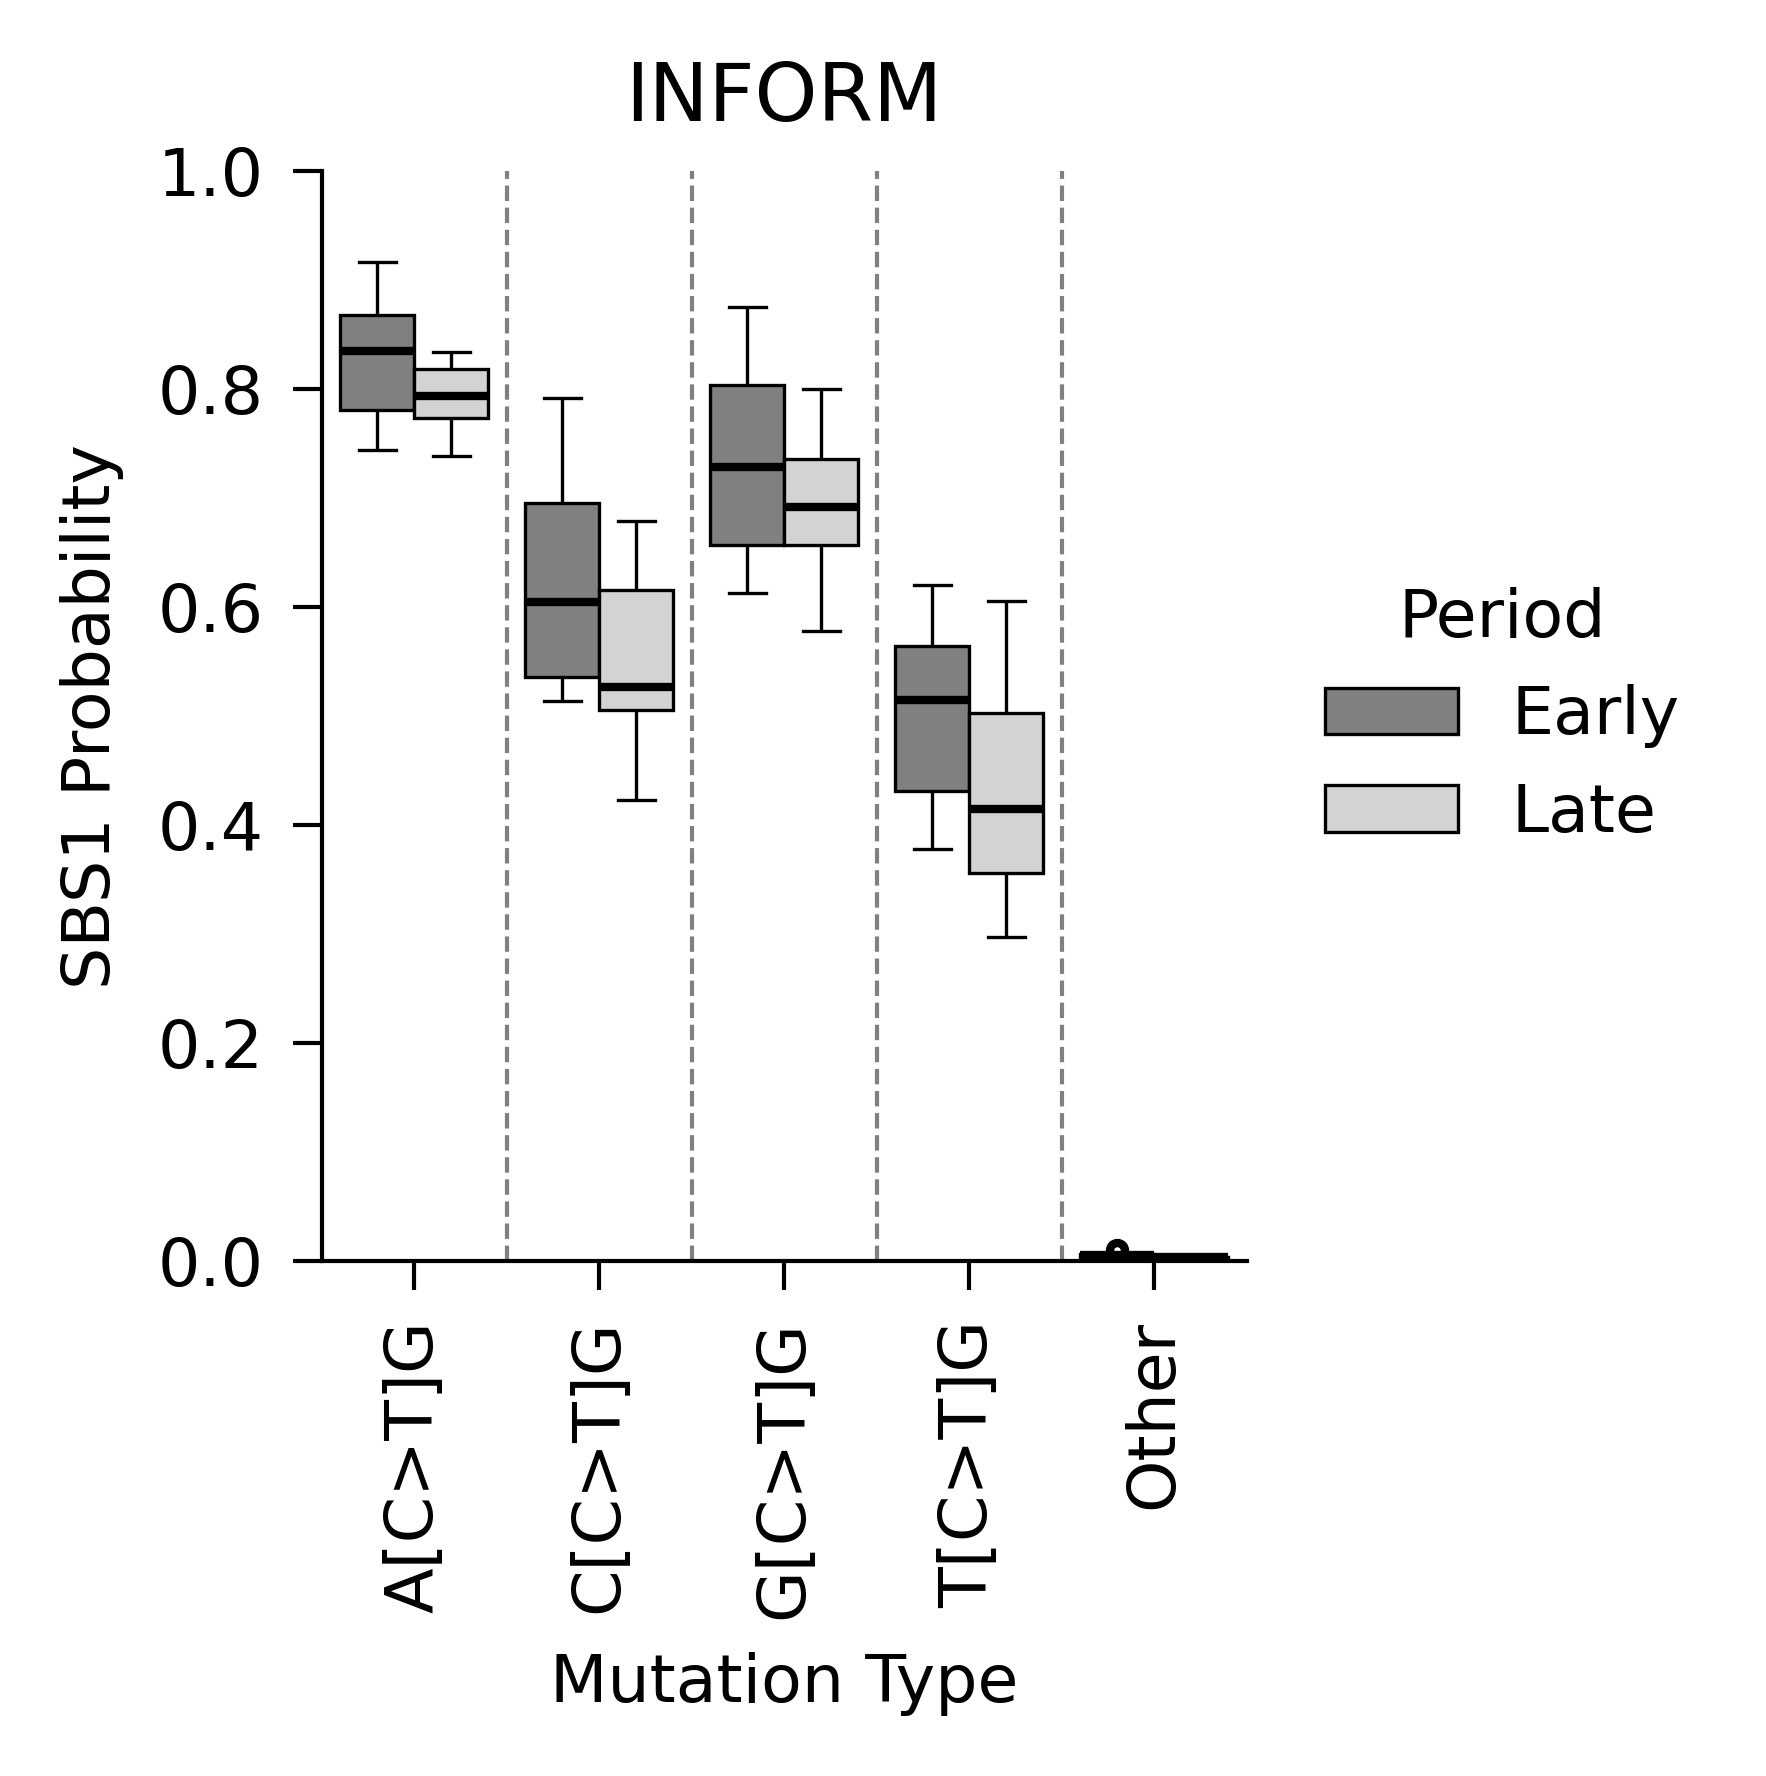

In [9]:
plot_sbs1_CpG_boxplot(
    cohort='INFORM',
    sample_ids_csv_path=f"{TIMING_DIR}/INFORM{TIMING_SUFFIX}",
    base_dir=f"{PREPROCESS_DIR}/INFORM",
    output_path=f"{OUT_DIR}/SBS1_INFORM_prob.pdf",
)